# 04 · Validation and verdict

**ORB study, notebook 4 of 5.** Question: do the frozen candidates (P0 and EXT_WIDTH) hold up on 2023-01-01 →
2024-12-31, which the selection never saw? BTC decides; ETH is the transfer test.

Continuation rule (PREREGISTRATION.md section 8), for each BTC candidate: net expectancy and mean daily return both
positive, at least three of four half-years positive, and non-negative expectancy with +5 bp per round trip. If no
candidate passes, the lockbox (2025-01-01 → 2026-09-13) stays closed and the verdict is taken from validation.

In [1]:
import json, subprocess, sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

STUDY = Path.cwd()
assert (STUDY / "PREREGISTRATION.md").exists(), "execute from studies/notebooks/orb_study"
sys.path.insert(0, str(STUDY))
import orb_calendars as cal, orb_checks, orb_data, orb_engine as eng, orb_metrics as met, orb_policies as pol
from review_plots import AXIS, INK2, MUTED, NEGATIVE, NEUTRAL, SERIES, style, zero_line
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40); pd.set_option("display.max_rows", 80)
RESULTS = STUDY / "results"

def reproduce(symbol, block, pid):
    # Recompute one frozen ledger from the panel and compare it with the saved file.
    import orb_run
    a, b = orb_run.BLOCKS[block]
    mkt = orb_checks.load_market(symbol)
    p = pol.BY_ID[pid]
    fresh = eng.run_policy(mkt, cal.sessions(p.anchor, "2020-01-01", b, shift_min=p.shift_min), p, a, b)
    if "exit_reason" in fresh:
        fresh.loc[(fresh["status"] == "trade") & (fresh["exit_reason"] == "censored_block_end"), "status"] = "censored"
    saved = pd.read_csv(RESULTS / f"run_v1/{block}/{symbol}/{pid}.csv.gz")
    num = ["t0_ms", "H", "L", "trigger_idx", "side", "fill_idx", "fill_px", "stop_px", "exit_idx", "exit_px", "gross_bp", "funding_bp"]
    same = len(fresh) == len(saved) and all(np.allclose(fresh[c].astype(float), saved[c].astype(float), equal_nan=True, rtol=0, atol=1e-9) for c in num)
    return bool(same and fresh["status"].tolist() == saved["status"].tolist())

import orb_run
orb_run.verify_f0()
F2, V = (json.loads((RESULTS / f"freeze_{n}.json").read_text()) for n in ("F2", "verdict"))
print("F2", F2["created_utc"], "| lockbox:", F2["lockbox"], "| verdict freeze", V["created_utc"])
print("validation ledgers reproduce from the panel:",
      {f"{s} {c}": reproduce(s, "validation", c) for s in ("BTCUSDT", "ETHUSDT") for c in F2["candidates"]})
VR = json.loads((RESULTS / "run_v1/validation/validation_report.json").read_text())

F2 2026-09-15T07:52:05+00:00 | lockbox: closed | verdict freeze 2026-09-15T07:52:23+00:00


validation ledgers reproduce from the panel: {'BTCUSDT P0': True, 'BTCUSDT EXT_WIDTH': True, 'ETHUSDT P0': True, 'ETHUSDT EXT_WIDTH': True}


In [2]:
rows = []
for sym, per in VR["assets"].items():
    for c, v in per.items():
        i = v["inference"]
        rows.append({"asset": sym, "candidate": c, "trades": v["trades"], "net_bp": i["mean_bp"], "ci95_lo": i["mean_bp_ci95"][0],
                     "ci95_hi": i["mean_bp_ci95"][2], "p_gt0": i["p_mean_bp_gt0"], "daily_mean_bp": i["daily_mean"] * 1e4,
                     "plus5_bp": v["db_plus5_mean_bp"], **{f"half {k}": x for k, x in v["halfyears"].items()}, "passes_rule": v["passes"]})
pd.DataFrame(rows).round(2)

,asset,candidate,trades,net_bp,ci95_lo,ci95_hi,p_gt0,daily_mean_bp,plus5_bp,half 2023-H1,half 2023-H2,half 2024-H1,half 2024-H2,passes_rule
0,BTCUSDT,P0,490,-6.84,-15.86,2.76,0.93,-4.58,-11.84,-9.80,-6.16,-4.20,-7.21,False
1,BTCUSDT,EXT_WIDTH,275,-10.85,-25.12,4.63,0.93,-4.08,-15.85,-16.07,6.23,-8.63,-23.39,False
2,ETHUSDT,P0,486,-7.15,-20.97,7.79,0.85,-4.75,-12.15,-14.12,8.61,-6.09,-16.81,False
3,ETHUSDT,EXT_WIDTH,276,-8.22,-26.72,12.05,0.80,-3.10,-13.22,-17.52,3.74,11.72,-30.56,False


## Half-year net expectancy, development into validation

The same frozen rules, one point per half-year, net of 11.6 bp costs and funding. The development block's positive
result rests on 2022; in validation every half-year is negative for P0.

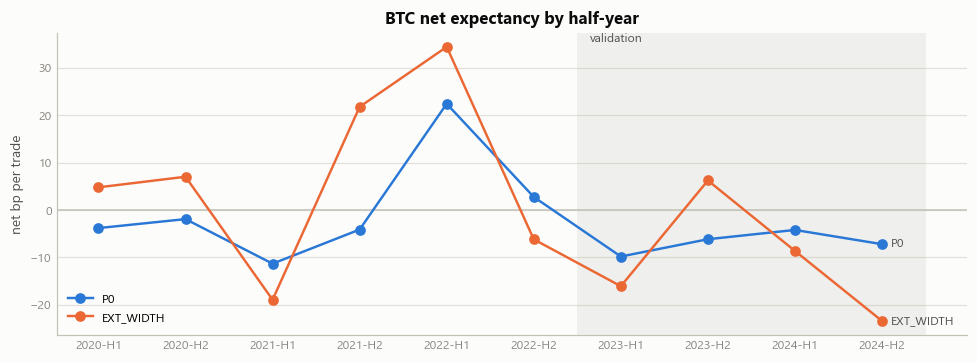

In [3]:
dev_h = pd.read_csv(RESULTS / "run_v1/development/halfyear_db_BTCUSDT.csv", index_col=0)
val = VR["assets"]["BTCUSDT"]
fig, ax = plt.subplots(figsize=(9, 3.4))
for i, c in enumerate(F2["candidates"]):
    s = pd.concat([dev_h.loc[c].dropna(), pd.Series(val[c]["halfyears"])])
    ax.plot(range(len(s)), s.values, marker="o", color=SERIES[i], label=c)
    ax.annotate(c, xy=(len(s) - 1, s.values[-1]), xytext=(6, 0), textcoords="offset points", fontsize=8, color=INK2, va="center")
ax.axvspan(5.5, len(s) - 0.5, color=NEUTRAL, alpha=0.18, linewidth=0)
ax.text(5.65, ax.get_ylim()[1], "validation", fontsize=8, color=INK2, va="top")
ax.set_xticks(range(len(s))); ax.set_xticklabels(s.index, fontsize=8)
style(ax); zero_line(ax); ax.set_ylabel("net bp per trade"); ax.set_title("BTC net expectancy by half-year"); ax.legend(loc="lower left")
plt.tight_layout(); plt.show()

## Verdict (frozen)

Neither candidate passed a single performance clause, so the lockbox was **not opened**. The registered verdict for
both is **INCONCLUSIVE + PRICE_SIGNAL_ONLY**. "Inconclusive" only because the upper end of the 95% interval (P0
+2.8 bp, EXT_WIDTH +4.6 bp) still reaches the +2 bp hurdle, not because the evidence leans positive: the point
estimates are −6.8 and −10.8 bp per trade, and ETH is no better (−7.2 and −8.2). Under the pre-registration a
validation failure ends this confirmatory campaign; a revised ORB idea needs a new ID and data not yet seen.

In [4]:
pd.DataFrame({c: {"verdict": " + ".join(v)} for c, v in V["verdicts"].items()}).T

,verdict
P0,INCONCLUSIVE + PRICE_SIGNAL_ONLY
EXT_WIDTH,INCONCLUSIVE + PRICE_SIGNAL_ONLY
